# import libraries

In [10]:
import re

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from networkx.algorithms.community import greedy_modularity_communities
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestRegressor,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.inspection import permutation_importance


plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid", font_scale=1.1)


In [11]:
def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9+# ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

## Load data

In [12]:
# Đặt đúng đường dẫn file trước khi chạy
JOB_POSTINGS_PATH = "../../data/postings.csv"
COMPANIES_PATH = "../../data/companies.csv"
EMP_COUNTS_PATH = "../../data/employee_counts.csv"
JOB_SKILLS_PATH = "../../data/job_skills.csv"
SKILL_MAP_PATH = "../../data/skill_mapping.csv"

job_df = pd.read_csv(JOB_POSTINGS_PATH)
companies_df = pd.read_csv(COMPANIES_PATH)
emp_counts_df = pd.read_csv(EMP_COUNTS_PATH)
job_skills_df = pd.read_csv(JOB_SKILLS_PATH)
skill_map_df = pd.read_csv(SKILL_MAP_PATH)


In [13]:
# Gộp để lấy tên kỹ năng đầy đủ
job_skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")

# Gom danh sách kỹ năng theo từng job_id
skills_per_job = (
    job_skills_full.dropna(subset=["skill_name"])
    .groupby("job_id")["skill_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"skill_name": "linkedin_skills"})
)

## Tích hợp dữ liệu

In [14]:
# Merge job với thông tin công ty
job_merged = job_df.merge(companies_df, on="company_id", how="left")

# Sau khi merge, có thể xuất hiện description_x (job) và description_y (company)
# Chuẩn hóa lại để luôn có đúng một cột 'description' cho mô tả job
desc_cols = [c for c in job_merged.columns if "description" in c]
if "description" not in job_merged.columns:
    # Ưu tiên description_x nếu có (từ job_df)
    if "description_x" in job_merged.columns:
        job_merged["description"] = job_merged["description_x"]
    elif len(desc_cols) > 0:
        job_merged["description"] = job_merged[desc_cols[0]]
# Xóa các cột description trùng lặp khác (giữ lại 'description')
for c in desc_cols:
    if c != "description":
        job_merged.drop(columns=[c], inplace=True)

# Lấy bản ghi employee_count mới nhất cho mỗi công ty
emp_latest = emp_counts_df.sort_values("time_recorded").groupby("company_id").tail(1)
job_merged = job_merged.merge(
    emp_latest[["company_id", "employee_count", "follower_count"]],
    on="company_id",
    how="left",
)

# Merge skill vào job_merged
job_merged = job_merged.merge(skills_per_job, on="job_id", how="left")

print("Kích thước sau khi merge:", job_merged.shape)
job_merged.head()

Kích thước sau khi merge: (123849, 42)


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,state,country,city,zip_code_y,address,url,description,employee_count,follower_count,linkedin_skills
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,...,NJ,US,Jersey City,07302,242 Tenth Street,https://www.linkedin.com/company/corcoran-sawy...,Job descriptionA leading real estate firm in N...,402.0,2351.0,"[Marketing, Sales]"
1,1829192,NaN,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...",NaN,NaN,[Health Care Provider]
2,10998357,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,...,Ohio,US,Mariemont,45227,6880 Wooster Pike,https://www.linkedin.com/company/the-national-...,The National Exemplar is accepting application...,15.0,40.0,"[Management, Manufacturing]"
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,...,New York,US,Lake Success,11042,3 Dakota Drive,https://www.linkedin.com/company/abrams-fenste...,Senior Associate Attorney - Elder Law / Trusts...,222.0,2427.0,[Other]
4,35982263,NaN,Service Technician,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Looking for HVAC service tech with experience ...,NaN,NaN,[Information Technology]


##  Tiền xử lí dữ liệu

In [15]:
# tạo cột mới chuẩn hóa description
job_merged["description_norm"] = (
    job_merged["description"].fillna("").apply(normalize_text)
)

# RQ2  

In [16]:
ESCO_SKILL_PATH = "../../data/skills_en.csv"
esco = pd.read_csv(ESCO_SKILL_PATH)
esco_raw = esco["preferredLabel"].dropna().astype(str)
esco_norm = esco_raw.apply(normalize_text)


GENERIC_SKILL_STOP = {
    "work",
    "team",
    "communication",
    "management",
    "business",
    "problem solving",
    "customer service",
    "time management",
    "leadership",
    "planning",
    "organise",
    "organize",
}


def is_valid_skill(term: str) -> bool:
    term = term.strip()
    if len(term) < 3:
        return False
    if term.isdigit():
        return False
    if len(term.split()) > 5:
        return False
    if term in GENERIC_SKILL_STOP:
        return False
    # loại cụm quá “động từ chung chung”
    if re.match(r"^(manage|assist|support|help|work|perform|provide)\b", term):
        return False
    return True


esco_clean = esco_norm[esco_norm.apply(is_valid_skill)].drop_duplicates()
esco_skills = esco_clean.tolist()
print("Số ESCO skills sau khi làm sạch:", len(esco_skills))
esco_skills[:20]

Số ESCO skills sau khi làm sạch: 11180


['supervise correctional procedures',
 'apply anti oppressive practices',
 'identify available services',
 'ensure coquille uniformity',
 'haskell',
 'show initiative',
 'apply diplomatic principles',
 'lead police investigations',
 'handle fish harvesting waste',
 'develop energy saving concepts',
 'sport and exercise medicine',
 'conduct research on flora',
 'install heat pump',
 'design biomass installations',
 'handle equipment while suspended',
 'teach housekeeping skills',
 'check train engines',
 'influence public policies',
 'enterprise risk management',
 'manufacture ingredients']

In [17]:
# desc_series_full = job_merged["description"].fillna("").apply(normalize_text)
desc_series_full = job_merged["description_norm"]

MAX_ROWS_NGRAM = 80000
if len(desc_series_full) > MAX_ROWS_NGRAM:
    desc_sample = desc_series_full.sample(MAX_ROWS_NGRAM, random_state=42)
else:
    desc_sample = desc_series_full

vec_all = CountVectorizer(
    ngram_range=(1, 4),
    min_df=30,
    max_df=0.75,
    token_pattern=r"[a-z0-9+#]+",
    stop_words="english",
)
vec_all.fit(desc_sample)
ngrams_all = set(vec_all.get_feature_names_out())
print("Tổng số n-gram từ mô tả:", len(ngrams_all))

Tổng số n-gram từ mô tả: 294821


In [18]:
esco_set = set(esco_skills)
skill_vocab = sorted(list(esco_set & ngrams_all))
print("Số ESCO skills thực sự xuất hiện trong corpus:", len(skill_vocab))
skill_vocab[:30]

Số ESCO skills thực sự xuất hiện trong corpus: 545


['abap',
 'accounting',
 'accounting entries',
 'achieve sales targets',
 'actuarial science',
 'acute care',
 'adhesives',
 'adjust priorities',
 'adobe creative suite',
 'adobe illustrator',
 'adobe photoshop',
 'adult education',
 'advanced materials',
 'advocate health',
 'aerospace engineering',
 'aesthetics',
 'agile development',
 'agile project management',
 'ajax',
 'alarm systems',
 'algebra',
 'algorithms',
 'allergies',
 'alternative energy',
 'analytical chemistry',
 'angular',
 'animal nutrition',
 'animal welfare',
 'ansible',
 'answer incoming calls']

In [19]:
vec_skill = CountVectorizer(
    vocabulary=skill_vocab,
    ngram_range=(1, 4),
    binary=True,
    token_pattern=r"[a-z0-9+#]+",
)
X_skill = vec_skill.fit_transform(desc_series_full)
skill_names = np.array(vec_skill.get_feature_names_out())
print("Ma trận doc x skill:", X_skill.shape)

Ma trận doc x skill: (123849, 545)


In [20]:
# Tạo skills_list cho từng job
skills_list = []
for i in range(X_skill.shape[0]):
    idx = X_skill[i].nonzero()[1]
    skills = skill_names[idx].tolist()
    skills_list.append(skills)

job_merged["skills_list"] = skills_list
job_merged[["title", "skills_list"]].head(10)

,title,skills_list
0,Marketing Coordinator,"[genetics, graphic design, plan]"
1,Mental Health Therapist/Counselor,"[crisis intervention, plan]"
2,Assitant Restaurant Manager,[]
3,Senior Elder Law / Trusts and Estates Associat...,[]
4,Service Technician,[]
5,Economic Development and Planning Intern,"[economics, geography, public administration, ..."
6,Producer,[motion graphics]
7,Building Engineer,"[building codes, english, plan, project manage..."
8,Respiratory Therapist,"[chemistry, control systems, plan, respiratory..."
9,Worship Leader,[team building]


In [ ]:
skills_transactions = job_merged["skills_list"]
skills_transactions = skills_transactions[skills_transactions.map(len) > 0]
print("Số job có ít nhất 1 skill ESCO:", len(skills_transactions))

te = TransactionEncoder()
te_ary = te.fit(skills_transactions.tolist()).transform(skills_transactions.tolist())
skills_ohe = pd.DataFrame(te_ary, columns=te.columns_)

X_bin = skills_ohe.values
N = X_bin.shape[0]

support = X_bin.mean(axis=0)
co_matrix = (X_bin.T @ X_bin) / N

skills = skills_ohe.columns.tolist()
pairs = []
for i in range(len(skills)):
    for j in range(i + 1, len(skills)):
        supp_ij = co_matrix[i, j]
        if supp_ij == 0:
            continue
        supp_i = support[i]
        supp_j = support[j]
        conf = supp_ij / supp_i if supp_i > 0 else 0
        lift = conf / supp_j if supp_j > 0 else 0
        pairs.append(
            {
                "skill_A": skills[i],
                "skill_B": skills[j],
                "support_AB": supp_ij,
                "support_A": supp_i,
                "support_B": supp_j,
                "confidence": conf,
                "lift": lift,
            }
        )

rules_esco = pd.DataFrame(pairs).sort_values("lift", ascending=False)
# lift_thresh = rules_esco["lift"].quantile(0.90)  # top 10% lift

rules_esco.head(20)

Số job có ít nhất 1 skill ESCO: 105979


,skill_A,skill_B,support_AB,support_A,support_B,confidence,lift
16070,corporate law,maintain privacy,0.000009,0.000604,0.000151,0.015625,103.495117
12759,collection management,policy analysis,0.000009,0.000255,0.000434,0.037037,85.329308
15581,control engineering,drive vehicles,0.000009,0.000349,0.000368,0.027027,73.443520
12762,collection management,process applications,0.000009,0.000255,0.000519,0.037037,71.366330
45196,supervise work,wind energy,0.000009,0.000293,0.000547,0.032258,58.942714
16518,counsel clients,immunotherapy,0.000009,0.000226,0.000736,0.041667,56.612714
31901,improve business processes,traffic engineering,0.000009,0.000377,0.000462,0.025000,54.070918
43137,psychiatric disorders,vocational rehabilitation,0.000009,0.000406,0.000434,0.023256,53.578868
577,accounting entries,policy analysis,0.000009,0.000406,0.000434,0.023256,53.578868
11861,circular economy,control engineering,0.000009,0.000510,0.000349,0.018519,53.042543


In [28]:
rules_esco.describe()

,support_AB,support_A,support_B,confidence,lift
count,4.552100e+04,45521.000000,45521.000000,45521.000000,45521.000000
mean,9.435832e-06,0.012640,0.013253,0.004543,1.752246
std,1.694085e-21,0.027264,0.034686,0.005490,3.815574
min,9.435832e-06,0.000151,0.000151,0.000028,0.000241
25%,9.435832e-06,0.001538,0.001368,0.000782,0.163110
50%,9.435832e-06,0.004190,0.003623,0.002252,0.512431
75%,9.435832e-06,0.012059,0.012267,0.006135,1.545334
max,9.435832e-06,0.333085,0.333085,0.062500,103.495117


In [23]:
# =========================
# 1) Hàm đánh giá 1 cấu hình ngưỡng
# =========================
def evaluate_threshold_config(
    rules_df: pd.DataFrame,
    lift_min: float,
    conf_min: float,
    top_edges_cap: int | None = 60,   # giữ tối đa bao nhiêu edges để graph dễ nhìn (None = không cap)
    use_weight: str = "lift",         # weight edge: "lift" hoặc "support_AB"
):
    # Lọc luật
    filt = rules_df[(rules_df["lift"] >= lift_min) & (rules_df["confidence"] >= conf_min)].copy()

    # Nếu bạn muốn graph "dễ nhìn" thì chỉ lấy top theo lift
    if top_edges_cap is not None and len(filt) > top_edges_cap:
        filt = filt.sort_values("lift", ascending=False).head(top_edges_cap)

    # Dựng graph
    G = nx.Graph()
    for _, r in filt.iterrows():
        w = float(r[use_weight])
        G.add_edge(r["skill_A"], r["skill_B"], weight=w)

    # Community detection (greedy modularity)
    if G.number_of_edges() > 0 and G.number_of_nodes() > 1:
        comms = list(greedy_modularity_communities(G))
        n_comms = len(comms)
        comm_sizes = [len(c) for c in comms]
        largest_comm = max(comm_sizes) if comm_sizes else 0
        avg_comm = float(np.mean(comm_sizes)) if comm_sizes else 0.0
    else:
        n_comms = 0
        largest_comm = 0
        avg_comm = 0.0

    return {
        "lift_min": lift_min,
        "conf_min": conf_min,
        "n_rules_after_filter": int(len(filt)),
        "n_nodes": int(G.number_of_nodes()),
        "n_edges": int(G.number_of_edges()),
        "n_communities": int(n_comms),
        "largest_community_size": int(largest_comm),
        "avg_community_size": float(avg_comm),
    }

In [ ]:
# =========================
# 2) Grid search ngưỡng
# =========================
lift_grid = [2.0, 2.5, 3.0, 3.5, 4.0]
conf_grid = [0.005, 0.01, 0.02]

rows = []
for lift_min in lift_grid:
    for conf_min in conf_grid:
        rows.append(
            evaluate_threshold_config(
                rules_esco,
                lift_min=lift_min,
                conf_min=conf_min,
                top_edges_cap=None,     
                use_weight="lift"
            )
        )

grid_results = pd.DataFrame(rows).sort_values(["lift_min", "conf_min"]).reset_index(drop=True)
display(grid_results)
grid_results.to_csv("grid_results.csv",index=False)

,lift_min,conf_min,n_rules_after_filter,n_nodes,n_edges,n_communities,largest_community_size,avg_community_size
0,2.0,0.005,5871,496,5871,5,168,99.200000
1,2.0,0.010,3386,485,3386,5,145,97.000000
2,2.0,0.020,512,281,512,11,61,25.545455
3,2.5,0.005,5233,480,5233,7,168,68.571429
4,2.5,0.010,3076,469,3076,6,140,78.166667
5,2.5,0.020,458,269,458,12,61,22.416667
6,3.0,0.005,4722,462,4722,5,167,92.400000
7,3.0,0.010,2840,451,2840,6,142,75.166667
8,3.0,0.020,421,256,421,11,50,23.272727
9,3.5,0.005,4251,438,4251,6,153,73.000000


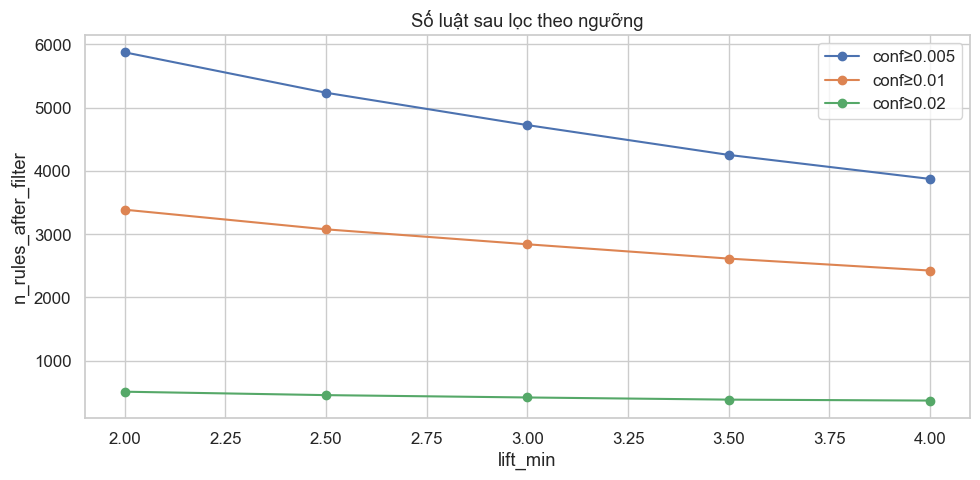

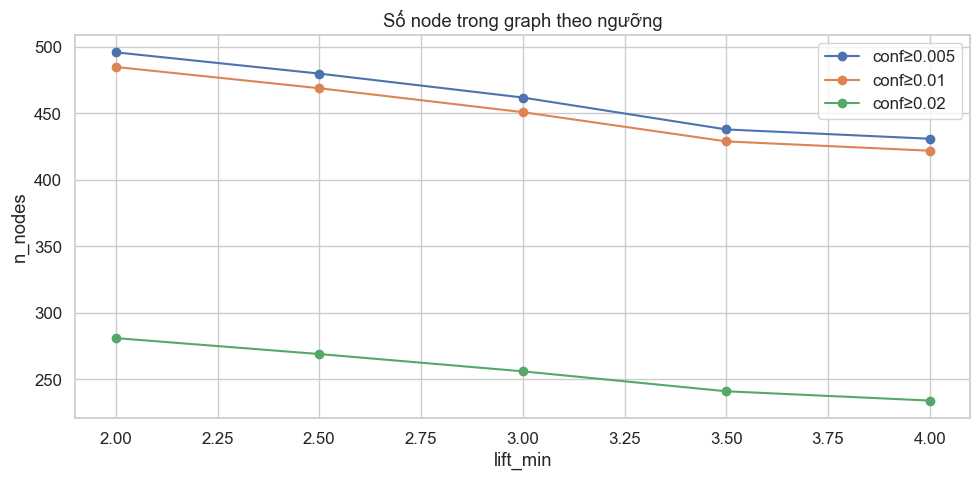

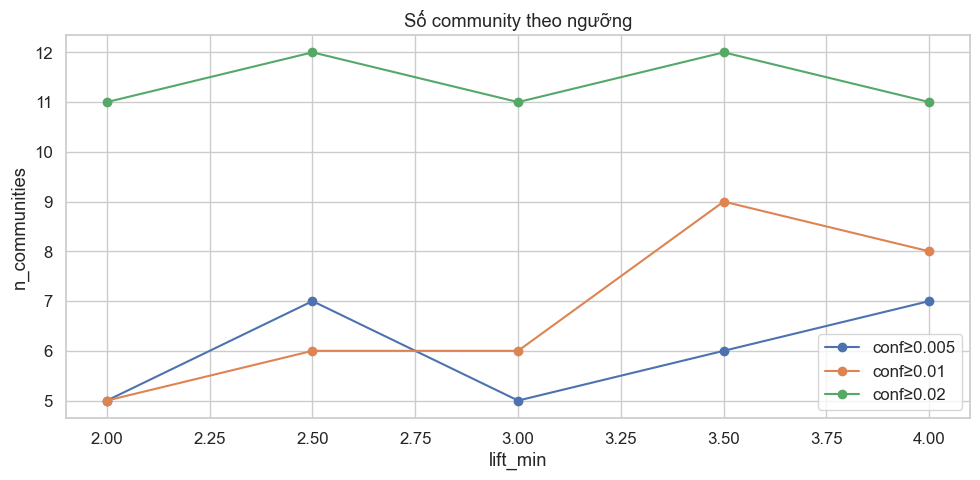

In [26]:
# =========================
# 3) Vẽ biểu đồ so sánh
# =========================
def plot_metric(df, metric, title):
    plt.figure(figsize=(10, 5))
    for conf_min in sorted(df["conf_min"].unique()):
        sub = df[df["conf_min"] == conf_min].sort_values("lift_min")
        plt.plot(sub["lift_min"], sub[metric], marker="o", label=f"conf≥{conf_min}")
    plt.xlabel("lift_min")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_metric(grid_results, "n_rules_after_filter", "Số luật sau lọc theo ngưỡng")
plot_metric(grid_results, "n_nodes", "Số node trong graph theo ngưỡng")
plot_metric(grid_results, "n_communities", "Số community theo ngưỡng")

In [ ]:
rules_esco = rules_esco[
    (rules_esco["lift"] >= 3.0) & (rules_esco["confidence"] >= 0.01)
]

In [31]:
TOP_EDGES = 60
top_rules = rules_esco.head(TOP_EDGES)

G = nx.Graph()
for _, r in top_rules.iterrows():
    G.add_edge(r["skill_A"], r["skill_B"], weight=r["lift"])

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

communities = list(greedy_modularity_communities(G))
print("Số community:", len(communities))
for i, comm in enumerate(communities):
    print(f"Community {i} size={len(comm)} sample={list(comm)[:10]}")

Nodes: 64 Edges: 60
Số community: 13
Community 0 size=11 sample=['lasers', 'energy storage systems', 'control engineering', 'supervise work', 'mobile device management', 'drive vehicles', 'circular economy', 'deliver outstanding service', 'wind energy', 'adjust priorities']
Community 1 size=11 sample=['transplantation', 'medical oncology', 'collection management', 'learning management systems', 'epidemiology', 'electronic communication', 'identify training needs', 'political science', 'counsel clients', 'immunotherapy']
Community 2 size=9 sample=['rheumatology', 'reverse engineering', 'instrumentation equipment', 'histology', 'biometrics', 'think analytically', 'biomarkers', 'tobacco products', 'scientific literature']
Community 3 size=8 sample=['contact customers', 'accounting entries', 'quantum computing', 'solve technical problems', 'capacity building', 'process applications', 'environmental policy', 'policy analysis']
Community 4 size=6 sample=['track key performance indicators', '

In [38]:
for lift in lift_grid:
    for conf in conf_grid:   
        print(f"\n==== lift = {lift}, confidence = {conf} ====")
        rules_esco_copy = rules_esco[
            (rules_esco["lift"] >= lift) & (rules_esco["confidence"] >= conf)
        ]
        TOP_EDGES = 60
        top_rules = rules_esco_copy.head(TOP_EDGES)

        G = nx.Graph()
        for _, r in top_rules.iterrows():
            G.add_edge(r["skill_A"], r["skill_B"], weight=r["lift"])

        print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

        communities = list(greedy_modularity_communities(G))
        print("Số community:", len(communities))
        for i, comm in enumerate(communities):
            print(f"Community {i} size={len(comm)} sample={list(comm)[:10]}")


==== lift = 2.0, confidence = 0.005 ====
Nodes: 64 Edges: 60
Số community: 13
Community 0 size=11 sample=['lasers', 'energy storage systems', 'control engineering', 'supervise work', 'mobile device management', 'drive vehicles', 'circular economy', 'deliver outstanding service', 'wind energy', 'adjust priorities']
Community 1 size=11 sample=['transplantation', 'medical oncology', 'collection management', 'learning management systems', 'epidemiology', 'electronic communication', 'identify training needs', 'political science', 'counsel clients', 'immunotherapy']
Community 2 size=9 sample=['rheumatology', 'reverse engineering', 'instrumentation equipment', 'histology', 'biometrics', 'think analytically', 'biomarkers', 'tobacco products', 'scientific literature']
Community 3 size=8 sample=['contact customers', 'accounting entries', 'quantum computing', 'solve technical problems', 'capacity building', 'process applications', 'environmental policy', 'policy analysis']
Community 4 size=6 sam

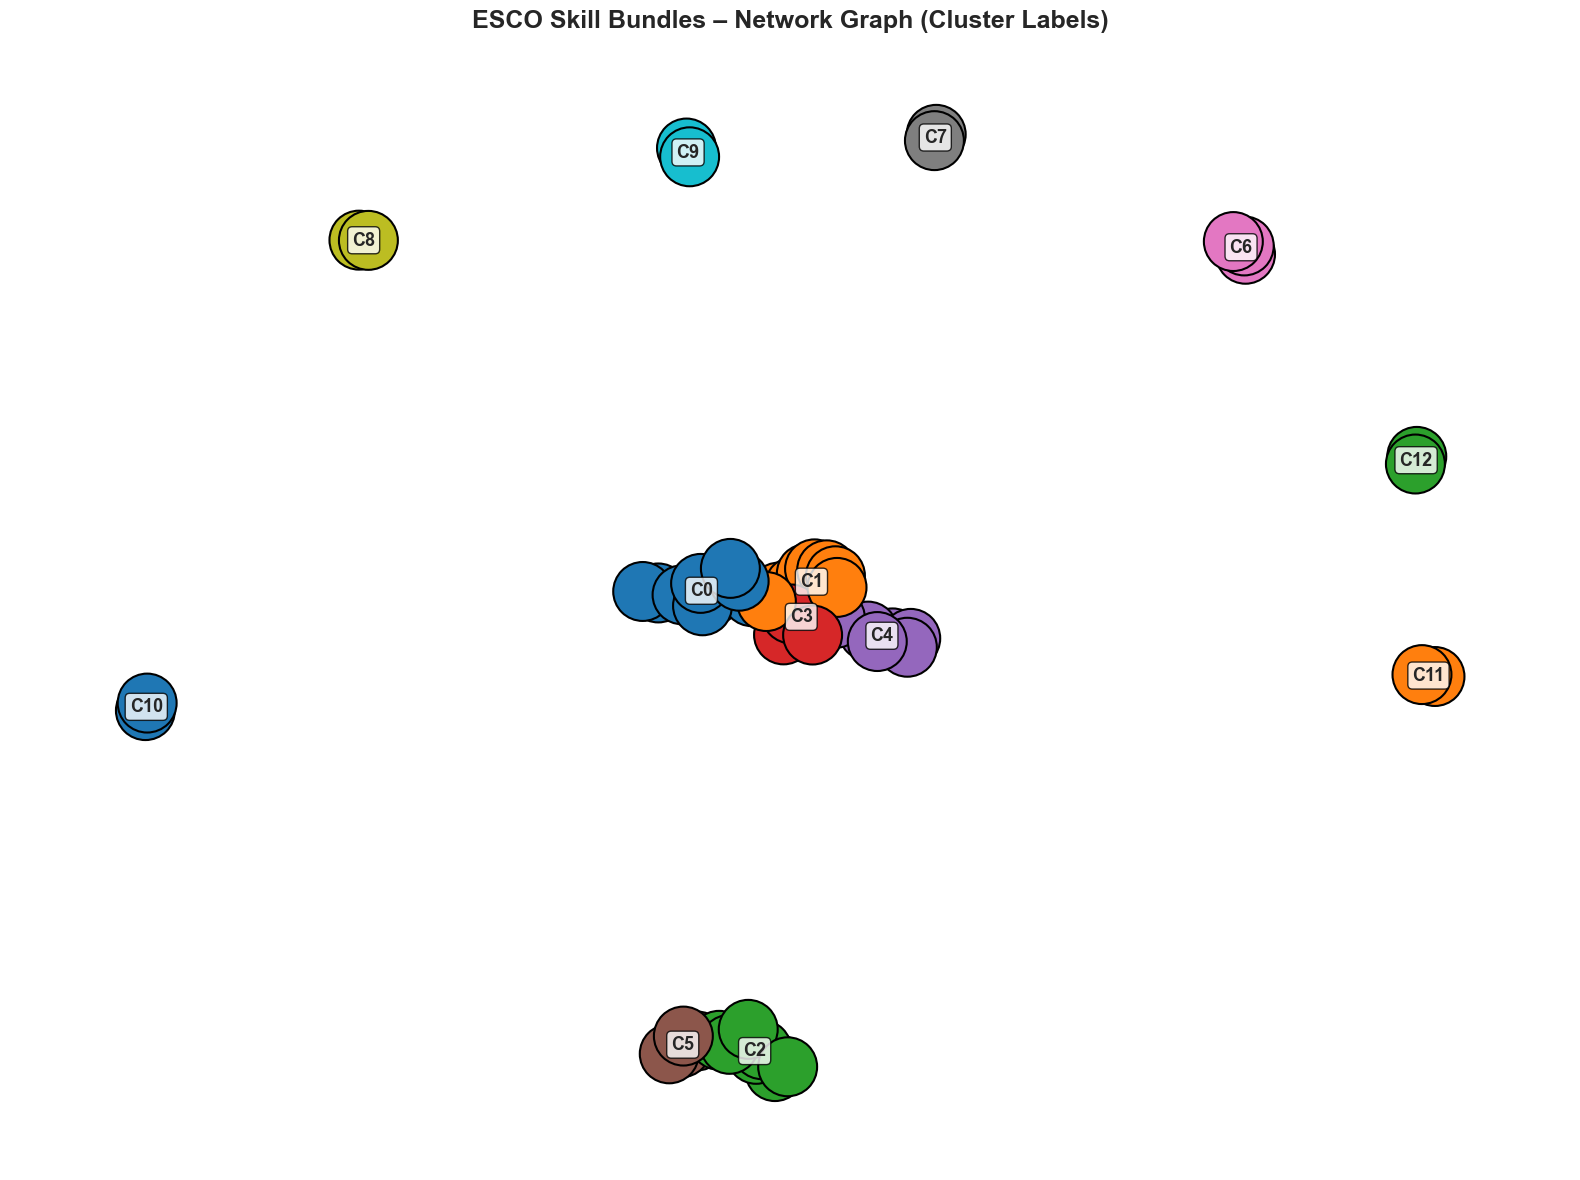

In [32]:
node2comm = {}
for cid, comm in enumerate(communities):
    for n in comm:
        node2comm[n] = cid

cmap = plt.get_cmap("tab10")
node_colors = [cmap(node2comm[n] % 10) for n in G.nodes()]

# Layout
pos = nx.spring_layout(G, k=1.3, iterations=500, seed=42)

plt.figure(figsize=(16, 12))

# Edge weights
edges = G.edges(data=True)
weights = np.array([d["weight"] for (_, _, d) in edges])
if len(weights) > 0:
    min_w, max_w = weights.min(), weights.max()
    if max_w > min_w:
        norm_w = 1 + 4 * (weights - min_w) / (max_w - min_w)
    else:
        norm_w = np.ones_like(weights)
else:
    norm_w = []

# Vẽ edges
nx.draw_networkx_edges(G, pos, edge_color="lightgray", width=norm_w, alpha=0.7)

# Vẽ nodes (có viền)
nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=1800, edgecolors="black", linewidths=1.5
)

# ======= LABEL CHO MỖI CỤM =======
# Tính tâm (mean) vị trí các node trong từng cụm

cluster_centers = {}
for cid, comm in enumerate(communities):
    xs = [pos[n][0] for n in comm]
    ys = [pos[n][1] for n in comm]
    cluster_centers[cid] = (np.mean(xs), np.mean(ys))

# Vẽ 1 label tại tâm cụm
for cid, (x, y) in cluster_centers.items():
    plt.text(
        x,
        y,
        f"C{cid}",
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8),
    )

plt.title(
    "ESCO Skill Bundles – Network Graph (Cluster Labels)",
    fontsize=18,
    fontweight="bold",
)
plt.axis("off")
plt.tight_layout()
plt.show()


In [33]:
# Tạo dict: community_id -> list skill (node)
community_dict = {
    cid: sorted(list(comm))  # sắp xếp cho dễ nhìn
    for cid, comm in enumerate(communities)
}

community_dict

{0: ['adjust priorities',
  'circular economy',
  'control engineering',
  'deliver outstanding service',
  'design management',
  'drive vehicles',
  'energy storage systems',
  'lasers',
  'mobile device management',
  'supervise work',
  'wind energy'],
 1: ['biostatistics',
  'collection management',
  'counsel clients',
  'electronic communication',
  'epidemiology',
  'identify training needs',
  'immunotherapy',
  'learning management systems',
  'medical oncology',
  'political science',
  'transplantation'],
 2: ['biomarkers',
  'biometrics',
  'histology',
  'instrumentation equipment',
  'reverse engineering',
  'rheumatology',
  'scientific literature',
  'think analytically',
  'tobacco products'],
 3: ['accounting entries',
  'capacity building',
  'contact customers',
  'environmental policy',
  'policy analysis',
  'process applications',
  'quantum computing',
  'solve technical problems'],
 4: ['computer programming',
  'improve business processes',
  'iterative devel

In [34]:
auto_cluster_names = {}

for cid, skills in community_dict.items():
    doc = " ".join(skills)
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf = vectorizer.fit_transform([doc])

    scores = tfidf.toarray()[0]
    top_ids = np.argsort(scores)[::-1][:3]  # 3 từ mạnh nhất
    keywords = [vectorizer.get_feature_names_out()[i] for i in top_ids]

    auto_cluster_names[cid] = " / ".join(keywords)

auto_cluster_names

{0: 'management / energy / vehicles',
 1: 'management / training / transplantation',
 2: 'tobacco / think / scientific',
 3: 'policy / technical / quantum',
 4: 'engineering / transportation / track',
 5: 'vocational / stem / social',
 6: 'engineering / packaging / materials',
 7: 'privacy / maintain / law',
 8: 'prescribe / medication / boxing',
 9: 'process / market / insurance',
 10: 'pesticides / chemistry / analytical',
 11: 'neonatology / loss / hearing',
 12: 'responsibilities / employees / delegate'}

In [35]:
def plot_community(G, community, cid):
    subG = G.subgraph(list(community))

    pos = nx.spring_layout(subG, k=1.2, iterations=400, seed=42)
    plt.figure(figsize=(16, 12))

    nx.draw_networkx_nodes(
        subG, pos, node_size=2400, node_color="#4A90E2", edgecolors="black"
    )

    nx.draw_networkx_edges(subG, pos, width=2, alpha=0.7, edge_color="gray")

    nx.draw_networkx_labels(subG, pos, font_size=11, font_weight="bold")

    # plt.title(f"Skill Bundle Cluster {auto_cluster_names[cid]}", fontsize=16)
    plt.title(f"cluster {cid}: {auto_cluster_names[cid]}", fontsize=16)
    plt.axis("off")
    plt.show()


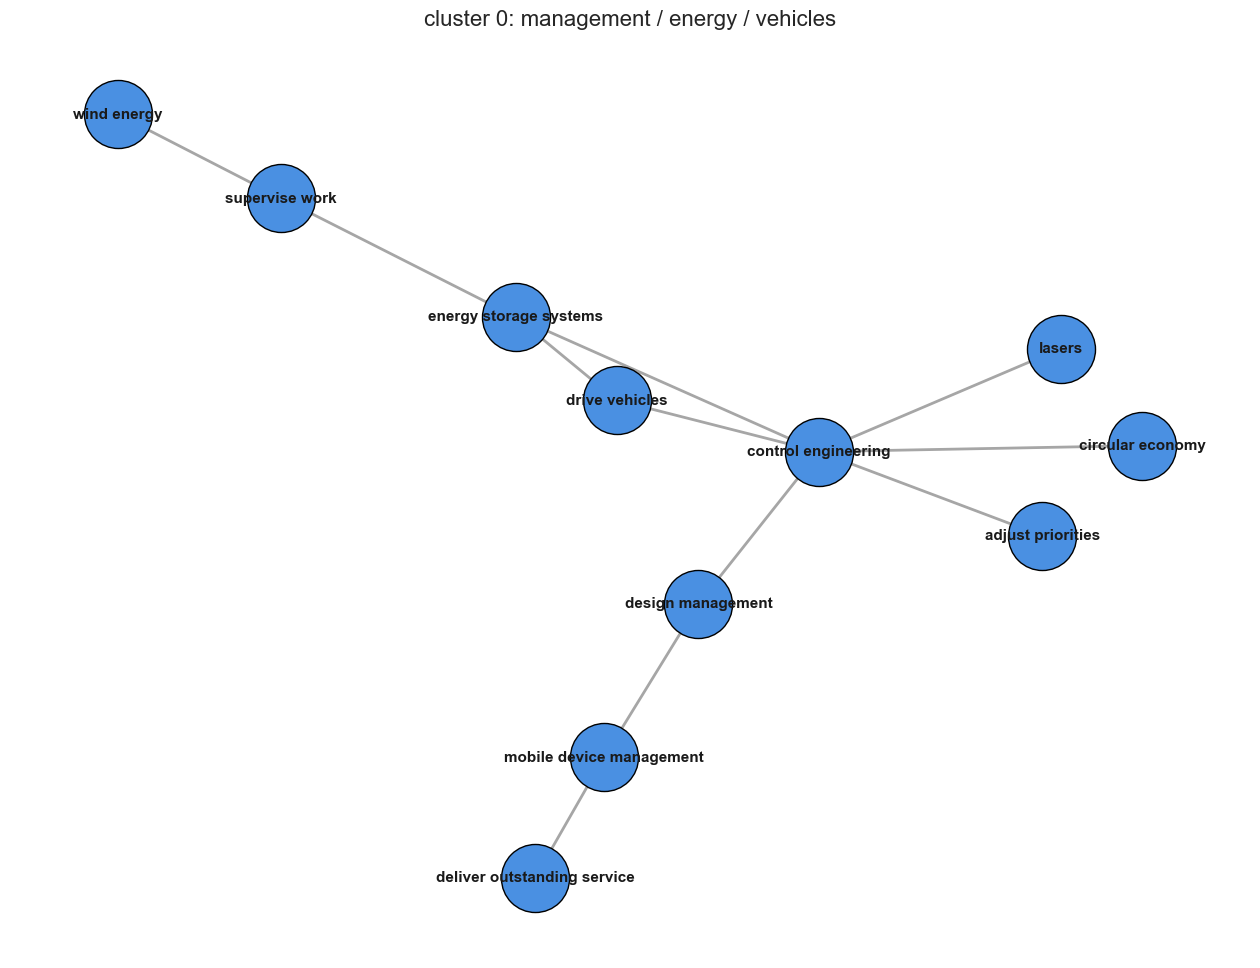

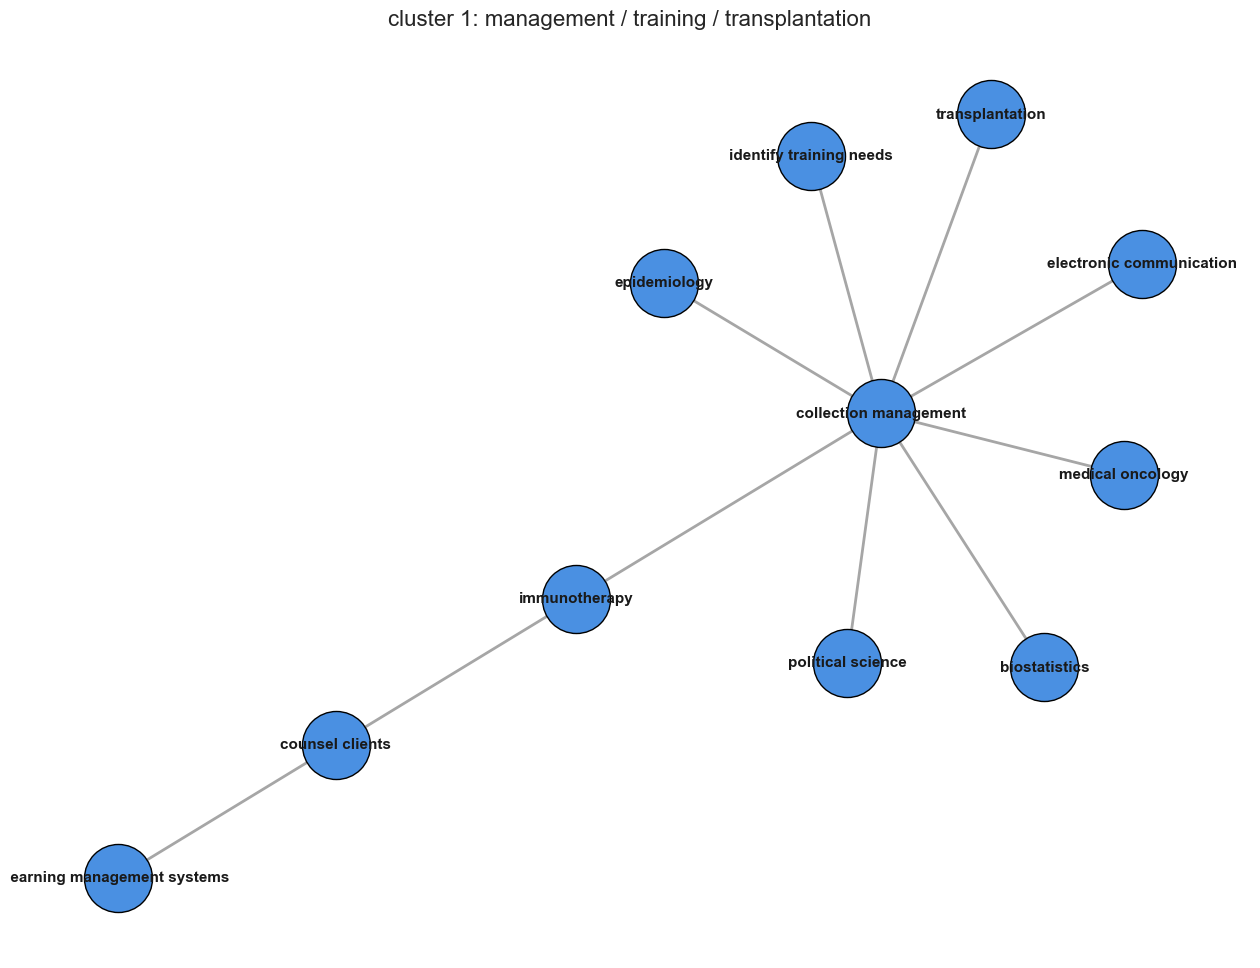

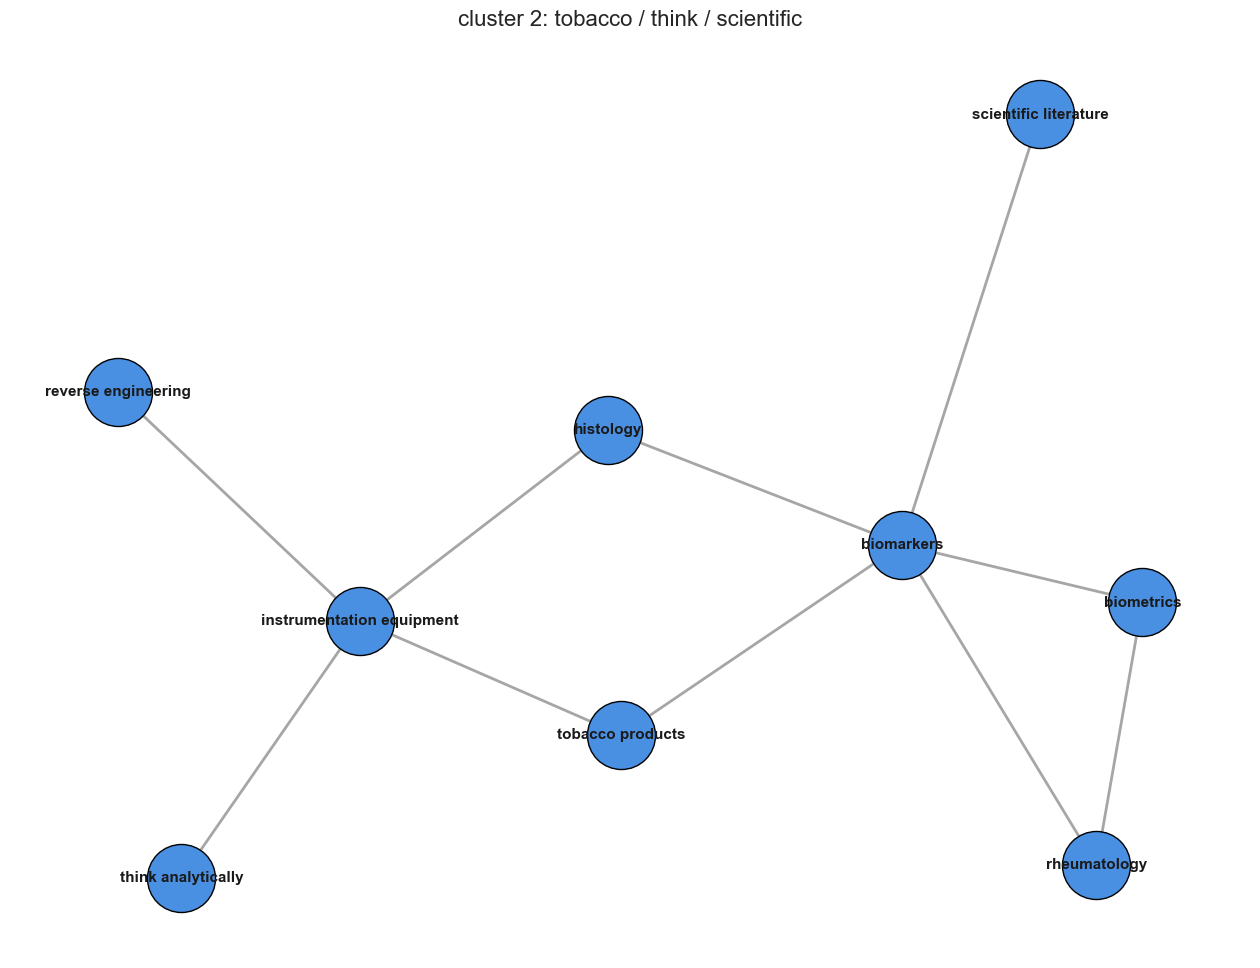

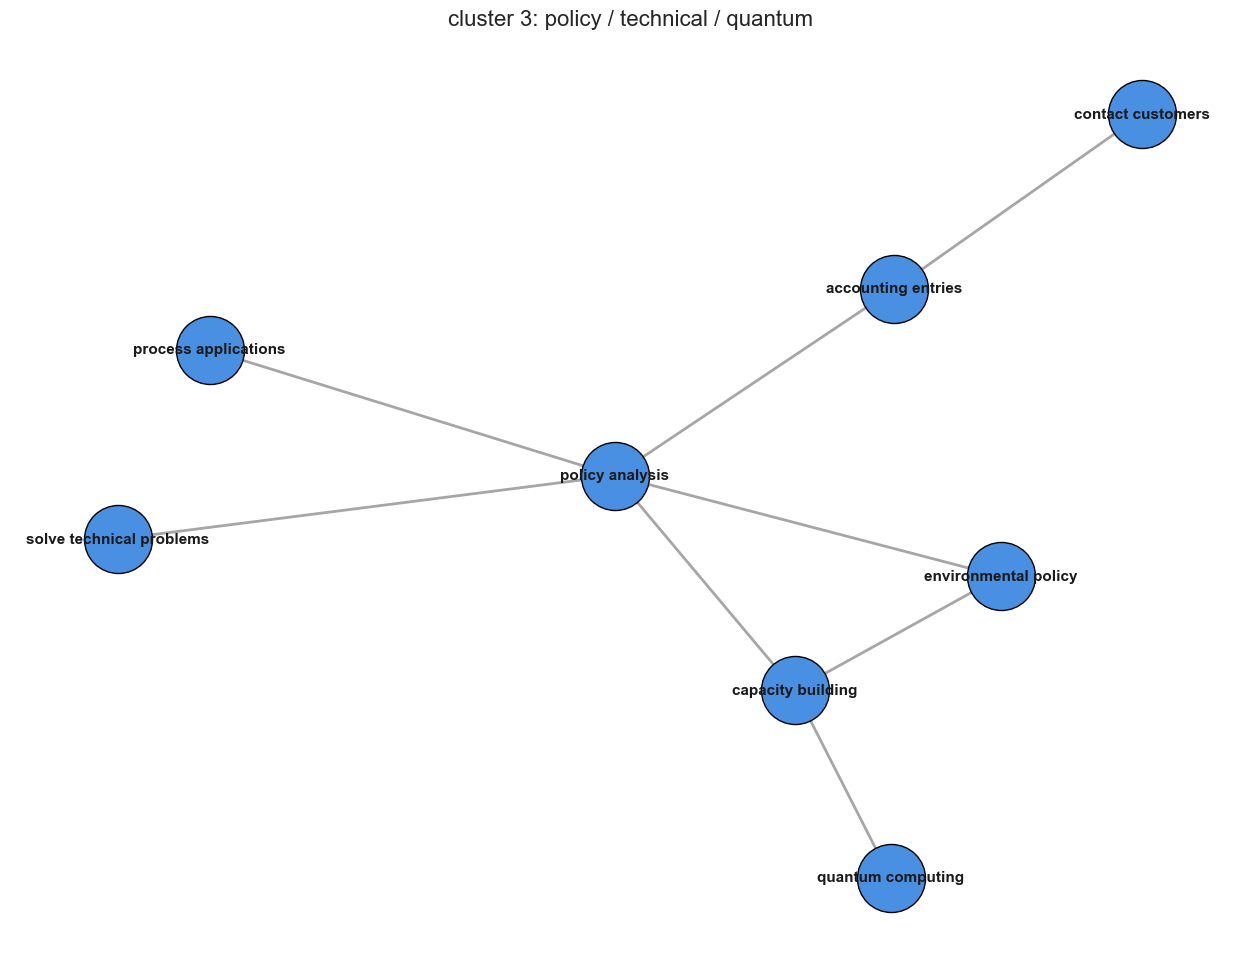

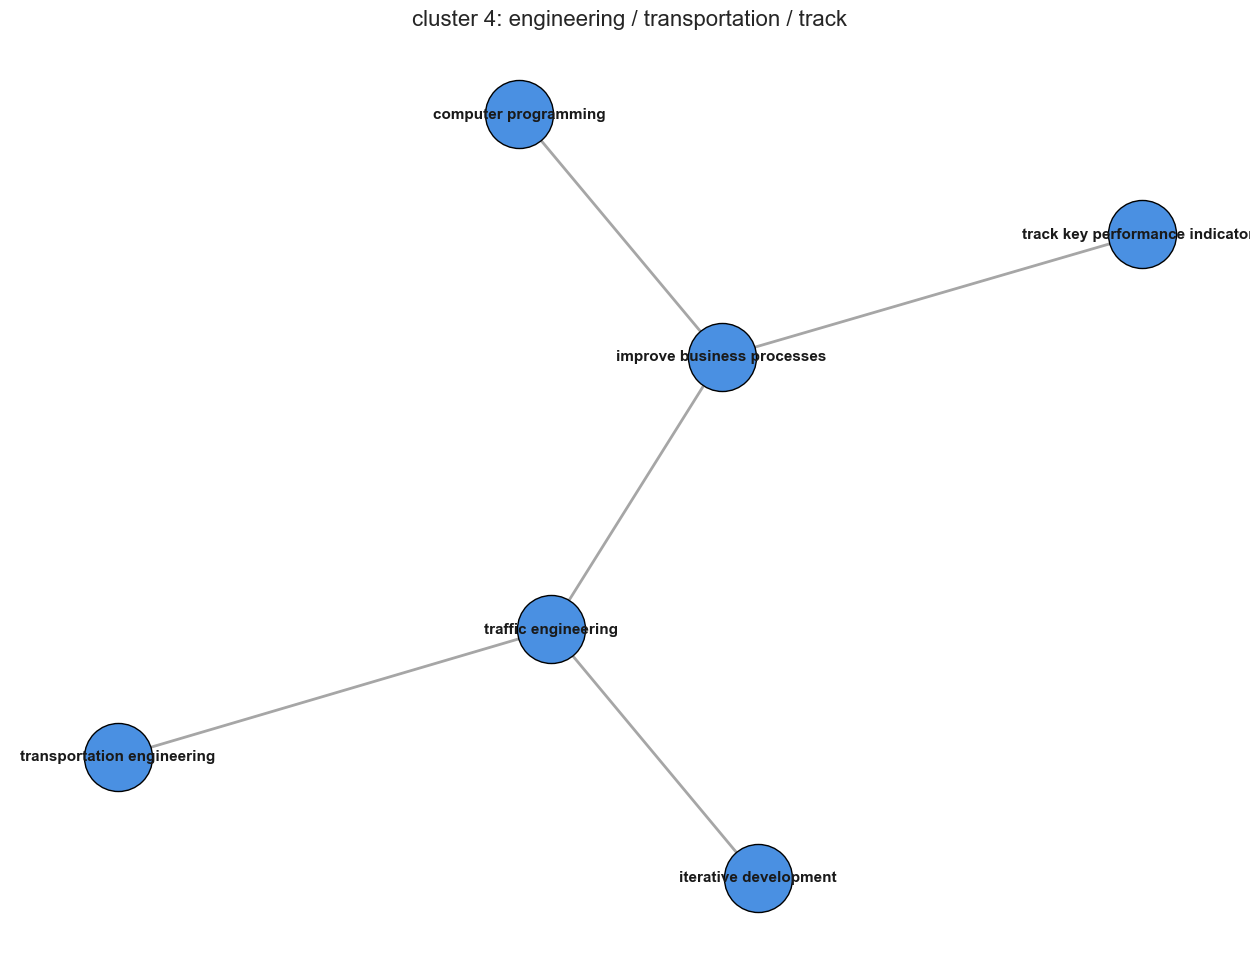

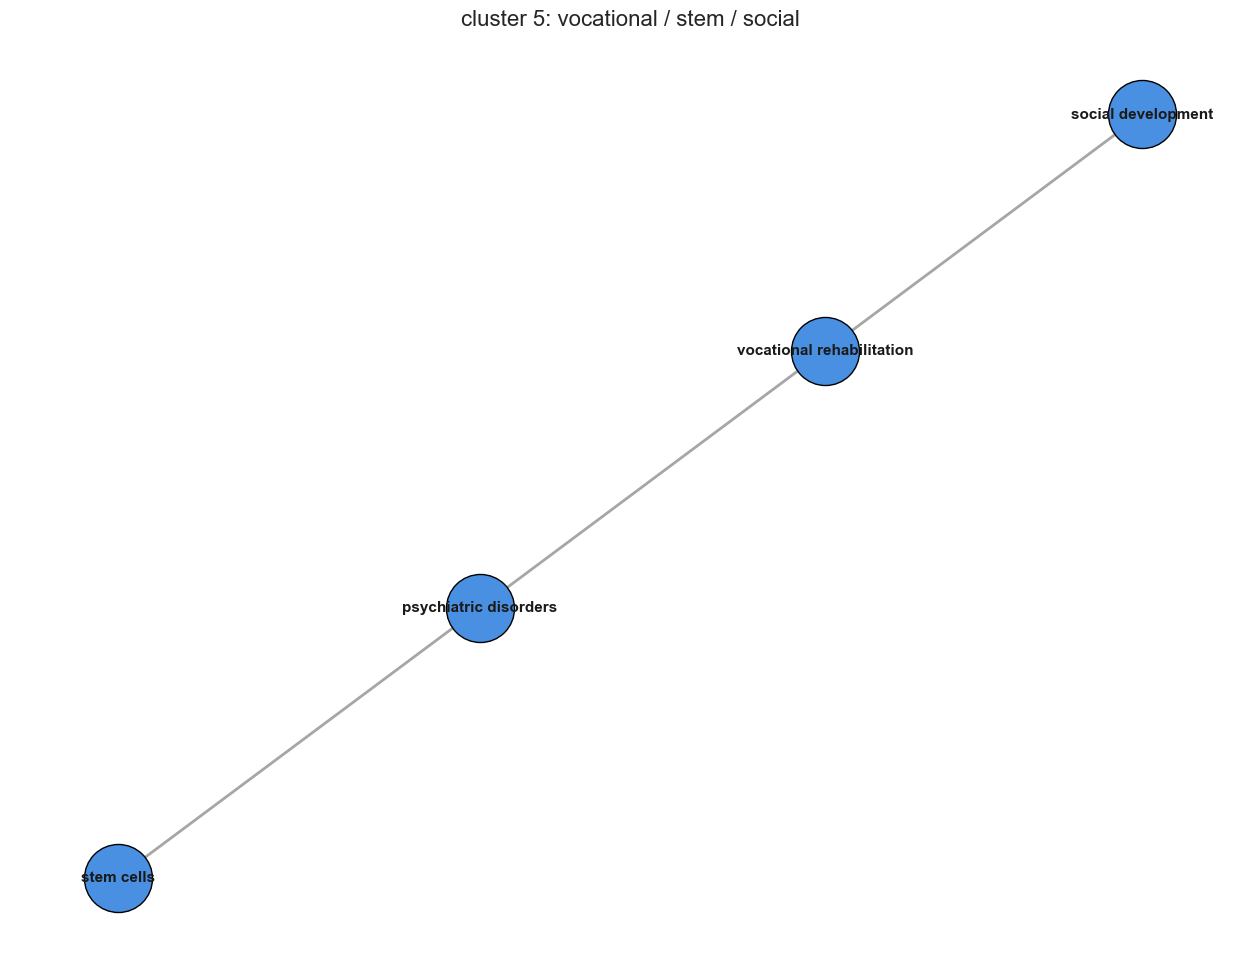

In [36]:
for cid, comm in enumerate(communities):
    if len(comm) >= 4:
        plot_community(G, comm, cid)